In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/heart_failure_clinical_records_dataset.csv")
df

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1,270,0
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0,271,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0,278,0
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1,280,0


In [ ]:
## Features:- ##

# Age: The age of the patient (numeric).

# Anaemia: Indicates the presence of anemia (binary: 0 for no, 1 for yes).

# Creatinine Phosphokinase (CPK): Level of creatinine phosphokinase enzyme in the blood (numeric).

# Diabetes: Indicates whether the patient has diabetes (binary: 0 for no, 1 for yes).

# Ejection Fraction: Percentage of blood leaving the heart at each contraction (numeric).

# High Blood Pressure: Indicates whether the patient has high blood pressure (binary: 0 for no, 1 for yes).

# Platelets: Platelet count in the blood (numeric).

# Serum Creatinine: Level of creatinine in the blood (numeric).

# Serum Sodium: Level of sodium in the blood (numeric).

# Sex: Gender of the patient (binary: 0 for female, 1 for male).

# Smoking: Indicates whether the patient smokes (binary: 0 for no, 1 for yes).

# Time: Follow-up period (in days) for the patient's condition (numeric).

# Death_event: Indicates whether the patient died during the follow-up period (binary: 0 for no, 1 for yes).

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


Mean Age: 60.83389297658862
Median Age: 60.0
Standard Deviation of Age: 11.89480907404447


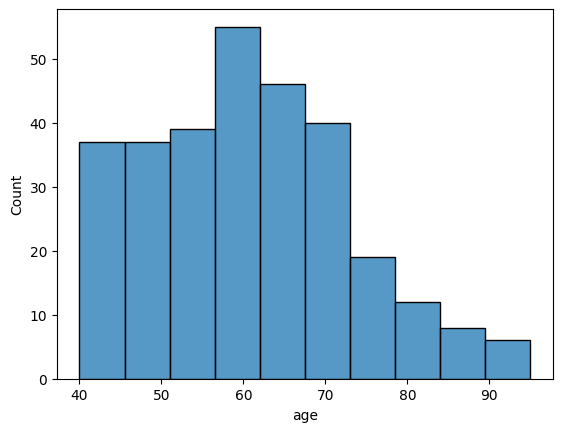

In [ ]:
# 1. What is the distribution of age among heart failure patients in the dataset?

# code

sns.histplot(df.age)

mean_age = df['age'].mean()
median_age = df['age'].median()
std_age = df['age'].std()

print(f'Mean Age: {mean_age}')
print(f'Median Age: {median_age}')
print(f'Standard Deviation of Age: {std_age}')

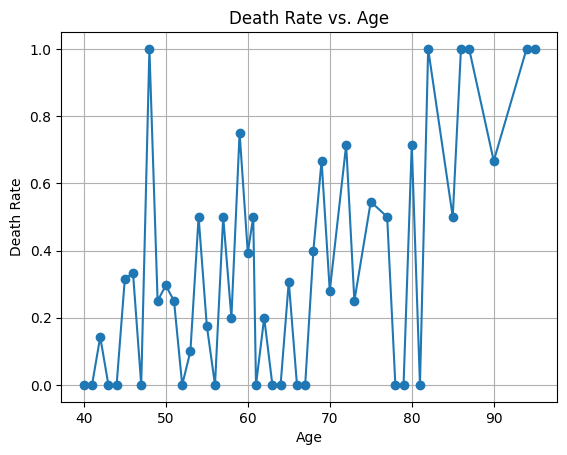

In [ ]:
# 2. How does the death rate vary with age?

# Calculate death rate for each age group
age_death_rate = df.groupby('age')['DEATH_EVENT'].mean()

# Plotting the death rate vs. age
plt.plot(age_death_rate.index, age_death_rate.values, marker='o', linestyle='-')
plt.title('Death Rate vs. Age')
plt.xlabel('Age')
plt.ylabel('Death Rate')
plt.grid(True)
plt.show()

In [ ]:
''' Insights : the patients age more than 80 are more likely to die. '''

' Insights : the patients age more than 80 are more likely to die. '

In [ ]:
## 3. What is the percentage of male and female patients in the dataset?

In [ ]:
# as per the dataset "male" = 1 and "female" = 0.
gender_count = df['sex'].value_counts(normalize=True)
male_percentage = gender_count[1] * 100
female_percentage = gender_count[0] * 100

print('Male Percentage : ',male_percentage)
print('Female Percentage : ',female_percentage)

Male Percentage :  64.88294314381271
Female Percentage :  35.11705685618729


In [ ]:
""" Insight : There are more male patients then female patients """

' Insight : There are more male patients then female patients '

In [ ]:
# 4. how does the platelet count vary from different age groups?

In [ ]:
bins = [40, 50, 60, 70, 80, 90]
labels = ['40-50', '50-60', '60-70', '70-80', '80-90']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

df['age_group']

,age_group
0,70-80
1,50-60
2,60-70
3,50-60
4,60-70
...,...
294,60-70
295,50-60
296,40-50
297,40-50


<Axes: xlabel='age_group', ylabel='platelets'>

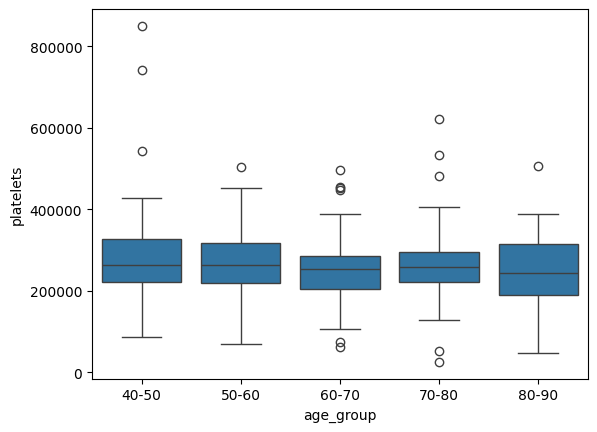

In [ ]:
sns.boxplot(x='age_group', y='platelets', data=df)

In [ ]:
mean_platelet_count = df.groupby('age_group')['platelets'].mean()
mean_platelet_count

<ipython-input-93-47f48363cd5c>:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_platelet_count = df.groupby('age_group')['platelets'].mean()


,platelets
age_group,
40-50,285931.705319
50-60,265001.807073
60-70,248990.840645
70-80,267036.349038
80-90,252248.213684


<Axes: xlabel='age_group'>

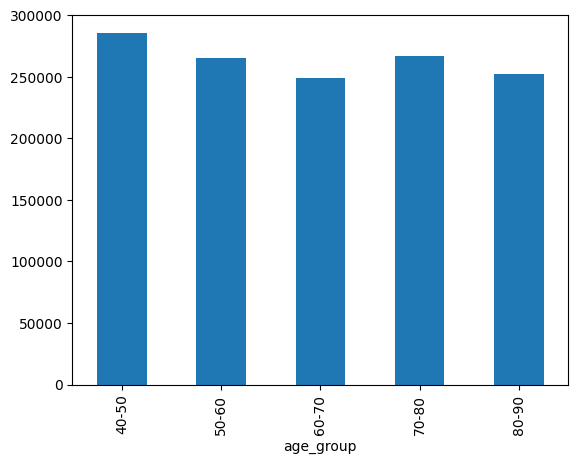

In [ ]:
mean_platelet_count.plot(kind='bar')

In [ ]:
''' Insights : age group 40-50 have have count of platelets and as age increases the platelets count decreases '''

' Insights : age group 40-50 have have count of platelets and as age increases the platelets count decreases '

In [ ]:
# 5.  Is there a correlation between creatinine and sodium levels in the blood.

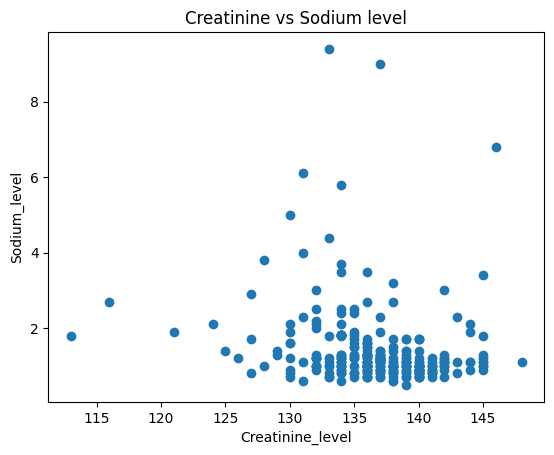

In [ ]:
#Ploting serum_creatinine vs serum_sodium:
plt.scatter(df["serum_sodium"],df["serum_creatinine"])

#Setting lebels
plt.xlabel("Creatinine_level")
plt.ylabel("Sodium_level")
plt.title("Creatinine vs Sodium level")

#Displaying the plot
plt.show()

In [ ]:
correlation = np.corrcoef(df["serum_sodium"], df["serum_creatinine"])[0, 1]

# Print the correlation coefficient
print("The correlation coefficient between serum_sodium and serum_creatinine is:", correlation)

The correlation coefficient between serum_sodium and serum_creatinine is: -0.1890952100911741


In [ ]:
''' Insights : A negative value of -0.18 indicates that as creatinine levels increase, sodium levels tend to decrease.'''

' Insights : A negative value of -0.18 indicates that as creatinine levels increase, sodium levels tend to decrease.'

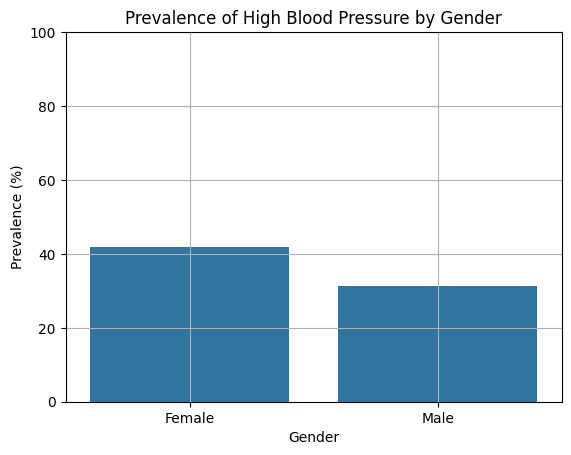

In [ ]:
# 6. How does the prevalence of high blood pressure differ between male and female patients?

prevalence = df.groupby('sex')['high_blood_pressure'].mean() * 100

prevalence.index = prevalence.index.map({1:"Male",0:"Female"})

sns.barplot(x=prevalence.index, y=prevalence.values)

plt.title('Prevalence of High Blood Pressure by Gender')
plt.xlabel('Gender')
plt.ylabel('Prevalence (%)')
plt.ylim(0, 100)  # Set y-axis limits from 0% to 100%
plt.grid(True)

In [ ]:
""" Insights : Compare to the Male, there is more percentage of Female having high blood pressure."""

' Insights : Compare to the Male, there is more percentage of Female having high blood pressure.'

In [ ]:
# 7. what is the relationship between smoking habits and the occurrence of heart failure.

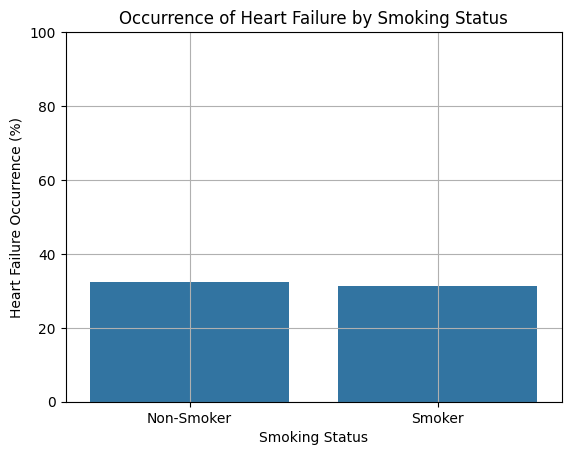

In [ ]:
death_rate = df.groupby('smoking')['DEATH_EVENT'].mean() * 100

death_rate.index = death_rate.index.map({1:"Smoker",0:"Non-Smoker"})

sns.barplot(x=death_rate.index, y=death_rate.values)

plt.title('Occurrence of Heart Failure by Smoking Status')
plt.xlabel('Smoking Status')
plt.ylabel('Heart Failure Occurrence (%)')
plt.ylim(0, 100)  # Set y-axis limits from 0% to 100%
plt.grid(True)

In [ ]:
''' Insights : The heart failure does not depends on if the patient is smoker or non-smoker'''

' Insights : The heart failure does not depends on if the patient is smoker or non-smoker'

In [133]:
# 8. Are there any noticeable patterns in the distribution of death events across different age groups.

In [135]:
# Calculate the proportion of death events by age group
death_event_rate = df.groupby('age_group')['DEATH_EVENT'].mean() * 100
death_event_rate

<ipython-input-135-503f506d2230>:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  death_event_rate = df.groupby('age_group')['DEATH_EVENT'].mean() * 100


,DEATH_EVENT
age_group,
40-50,23.404255
50-60,24.390244
60-70,29.032258
70-80,38.461538
80-90,68.421053


<Axes: xlabel='age_group'>

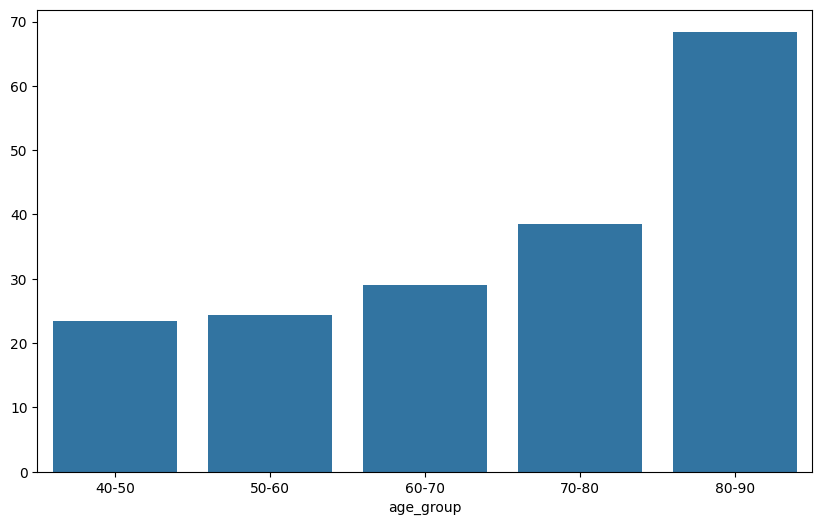

In [137]:
plt.figure(figsize=(10, 6))
sns.barplot(x=death_event_rate.index, y=death_event_rate.values)

In [138]:
""" Insights : The death event increases as the age increases. The age group of 40-50 has low death event and increases in further age groups"""

' Insights : The death event increases as the age increases. The age group of 40-50 has low death event and increases in further age groups'

In [139]:
# 9. Is there any significant difference in ejection fraction between patients with and without diabetes.

In [140]:
# 10. How does the serum creatinine level vary between patients who survived and those who did not?

<ipython-input-141-04200207d180>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='DEATH_EVENT', y='serum_creatinine', data=df, palette='Set1')


<Axes: xlabel='DEATH_EVENT', ylabel='serum_creatinine'>

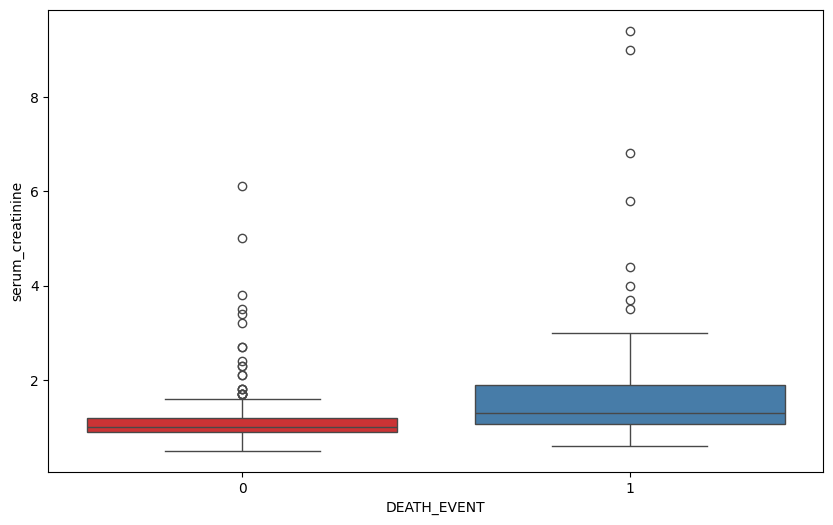

In [141]:
# Separate serum creatinine levels based on survival status
survived_creatinine = df[df['DEATH_EVENT'] == 0]['serum_creatinine']
not_survived_creatinine = df[df['DEATH_EVENT'] == 1]['serum_creatinine']

# Visualize the distribution using a boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='DEATH_EVENT', y='serum_creatinine', data=df, palette='Set1')